In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df=pd.read_csv('placement.csv')

In [5]:
df.sample(5)

,cgpa,package
179,7.14,3.03
157,6.47,2.70
195,6.93,2.46
187,6.26,2.44
65,7.60,3.81


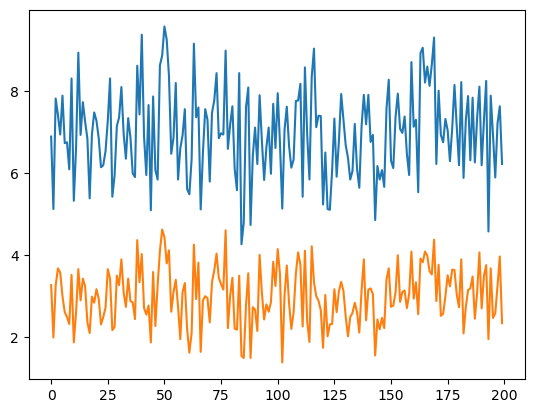

In [6]:
plt.plot(df)

Text(0.5, 1.0, 'sctter plot of placement data set')

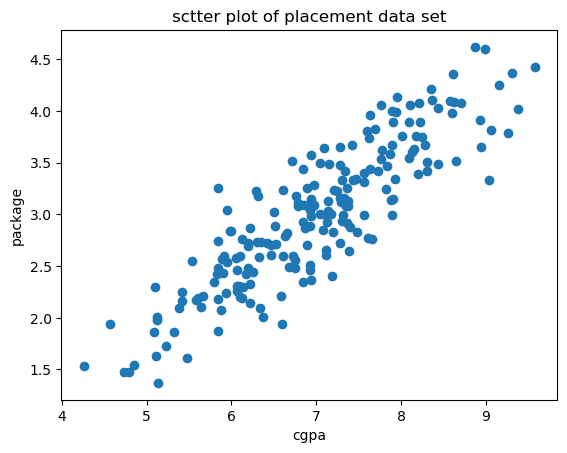

In [7]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel("cgpa")
plt.ylabel('package')
plt.title('sctter plot of placement data set')

In [8]:
df.describe()

,cgpa,package
count,200.000000,200.000000
mean,6.990500,2.996050
std,1.069409,0.691644
min,4.260000,1.370000
25%,6.190000,2.487500
50%,6.965000,2.995000
75%,7.737500,3.492500
max,9.580000,4.620000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [10]:
x=df.iloc[:,0:1]
y=df.iloc[:,-1]

In [11]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=45)

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
lr=LinearRegression()

In [16]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Text(0.5, 1.0, 'sctter plot of placement data set')

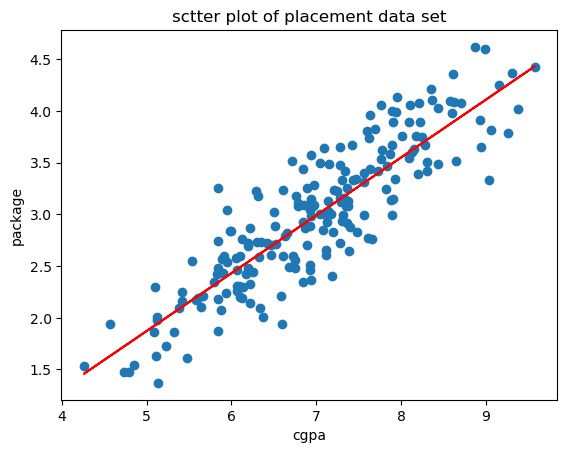

In [17]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(x_train,lr.predict(x_train),color='red')
plt.xlabel("cgpa")
plt.ylabel('package')
plt.title('sctter plot of placement data set')

In [20]:
y_pred=lr.predict(x_test)

In [21]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

## Matrices of the trained linear model

In [23]:
mae=mean_absolute_error(y_test,y_pred)

In [24]:
mae

0.23968176547795603

In [25]:
mse=mean_squared_error(y_test,y_pred)

In [26]:
mse

0.08836640586082933

In [27]:
rmse=np.sqrt(mse)

In [28]:
rmse

np.float64(0.2972648749193711)

In [29]:
r2=r2_score(y_test,y_pred)

In [30]:
r2

0.8061011005760799

In [34]:
#Adusted r2 score
adj_r2=(1-((1-r2)*(x_test.shape[0])/(x_test.shape[0]-1-x_test.shape[1])))

In [35]:
adj_r2

0.795895895343242

In [36]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.369826,3.26
1,5.12,0.373506,1.98
2,7.82,0.793960,3.25
3,7.42,0.741598,3.67
4,6.94,0.856578,3.57


Text(0, 0.5, 'Package')

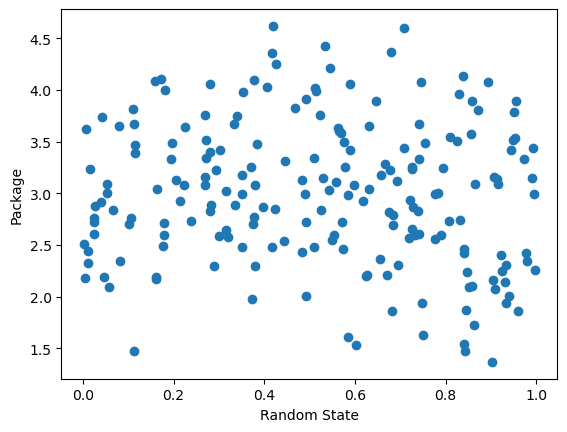

In [42]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('Random State')
plt.ylabel('Package')

In [43]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [44]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [45]:
lr = LinearRegression()

In [46]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
y_pred = lr.predict(X_test)

In [48]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.7797121334495125


In [49]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.7678046812035402

In [50]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]

Text(0, 0.5, 'Package(in lpa)')

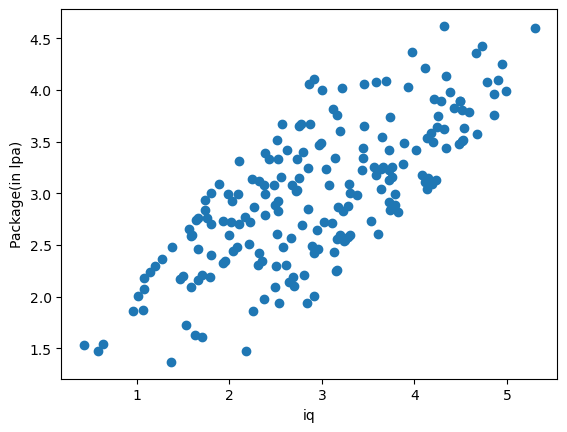

In [51]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [52]:
np.random.randint(-100,100)

-34

In [53]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [54]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [55]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [56]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.8382828074959773


In [57]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.829541337630895